# Logistic Regression From Scratch — MNIST Phase 1

**Binary classification:** target digit vs all other digits.

- Internally the model uses labels **0** and **1**.
- Final display uses **Class 1** (target digit) and **Class 2** (all others).

**Mathematical formulation:**
- Input:  $ X \in \mathbb{R}^{n \times d} $ where $d$ = number of features (784 for flatten, 100 for PCA, varies for HOG)
- Output: $ \hat{y} = \sigma(Xw + b) $, where $ \sigma(z) = \frac{1}{1 + e^{-z}} $
- Loss:   Binary Cross-Entropy $ \mathcal{L} = -\frac{1}{n}\sum [y\log(\hat{y}) + (1-y)\log(1-\hat{y})] $
- Gradients: $ \frac{\partial \mathcal{L}}{\partial w} = \frac{1}{n} X^T (\hat{y} - y) $, $ \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n} \sum (\hat{y} - y) $
- Update:  $ w \leftarrow w - \alpha \frac{\partial \mathcal{L}}{\partial w} $, $ b \leftarrow b - \alpha \frac{\partial \mathcal{L}}{\partial b} $

Keep this notebook in the same folder as `preprocessing.py`.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing import preprocess_mnist


## 1. Experiment settings

Change `method` to `"flatten"`, `"pca"`, or `"hog"`.

> **Note:** Always restart the kernel and run all cells top-to-bottom before recording results, to avoid stale variable values from previous runs.


In [ ]:
target_digit = 0
method       = "flatten"   # "flatten", "pca", or "hog"
pca_components = 100

learning_rate = 0.05
epochs        = 700      # increased from 300 — ensures the model fully converges


## 2. Load and preprocess data

Creates training, validation, and test sets.
Also returns `mean` and `std` so we can undo standardisation for image visualisation later.


In [11]:
X_train, y_train, X_val, y_val, X_test, y_test= preprocess_mnist(
    target_digit=target_digit,
    method=method,
    pca_components=pca_components
)

print("Method      :", method)
print("Target digit:", target_digit)
print("X_train     :", X_train.shape)
print("X_val       :", X_val.shape)
print("X_test      :", X_test.shape)

print("\nTraining class distribution:")
n_pos = np.sum(y_train == 1)
n_neg = np.sum(y_train == 0)
print(f"  Class 1 (digit {target_digit}): {n_pos}")
print(f"  Class 2 (others)  : {n_neg}")
print(f"  Imbalance ratio   : 1 : {n_neg // n_pos}")


Method      : flatten
Target digit: 5
X_train     : (51000, 784)
X_val       : (9000, 784)
X_test      : (10000, 784)

Training class distribution:
  Class 1 (digit 5): 4594
  Class 2 (others)  : 46406
  Imbalance ratio   : 1 : 10


## 3. Logistic regression — manual implementation

All maths is done from scratch using NumPy only.

| Function | Formula |
|---|---|
| Sigmoid | $ \sigma(z) = 1 / (1 + e^{-z}) $ |
| Loss (BCE) | $ -\frac{1}{n}\sum y\log(\hat{y}) + (1-y)\log(1-\hat{y}) $ |
| Gradient dW | $ \frac{1}{n} X^T (\hat{y} - y) $ |
| Gradient db | $ \frac{1}{n} \sum (\hat{y} - y) $ |


In [18]:
def sigmoid(z):
    """Numerically stable sigmoid."""
    return 1 / (1 + np.exp(-z))


def compute_loss(y_true, y_pred):
    """Binary cross-entropy loss with epsilon guard against log(0)."""
    epsilon = 1e-8
    return -np.mean(
        y_true * np.log(y_pred + epsilon) +
        (1 - y_true) * np.log(1 - y_pred + epsilon)
    )


def predict_probability(X, W, b):
    """Forward pass: compute P(y=1 | X)."""
    z = np.dot(X, W) + b
    return sigmoid(z)


def predict_binary(X, W, b, threshold=0.5):
    """Hard classification at given probability threshold."""
    probabilities = predict_probability(X, W, b)
    return np.where(probabilities >= threshold, 1, 0)


def convert_to_class_1_class_2(predictions):
    """Convert internal 0/1 labels to Class 1 / Class 2 for display."""
    return np.where(predictions == 1, 1, 2)


## 4. Train model

- **Training set** updates weights every epoch.
- **Validation set** monitors generalisation — weights are never updated using it.
- Best weights (lowest validation loss) are saved and restored after training (early stopping / model checkpointing).


In [19]:
m, n = X_train.shape

# Initialise weights to zero
W = np.zeros(n)
b = 0.0

train_losses = []
val_losses   = []

best_val_loss = float("inf")
best_W        = W.copy()
best_b        = b
best_epoch    = 0

for epoch in range(epochs):

    # --- Forward pass (training) ---
    y_pred     = predict_probability(X_train, W, b)
    train_loss = compute_loss(y_train, y_pred)

    # --- Gradients ---
    error = y_pred - y_train                          # shape (m,)
    dW    = (1 / m) * np.dot(X_train.T, error)       # shape (n,)
    db    = (1 / m) * np.sum(error)                  # scalar

    # --- Gradient descent update ---
    W = W - learning_rate * dW
    b = b - learning_rate * db

    # --- Validation loss (no weight update) ---
    val_pred = predict_probability(X_val, W, b)
    val_loss = compute_loss(y_val, val_pred)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # --- Model checkpointing: save best weights ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_W        = W.copy()
        best_b        = b
        best_epoch    = epoch

    if epoch % 100 == 0:
        print(f"Epoch {epoch:04d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# Restore best weights
W = best_W
b = best_b

print("\nTraining finished.")
print("Best validation epoch:", best_epoch)
print("Best validation loss :", round(best_val_loss, 4))


Epoch 0000 | Train Loss: 0.6931 | Val Loss: 0.6690
Epoch 0100 | Train Loss: 0.2670 | Val Loss: 0.2667
Epoch 0200 | Train Loss: 0.1914 | Val Loss: 0.1933
Epoch 0300 | Train Loss: 0.1604 | Val Loss: 0.1632
Epoch 0400 | Train Loss: 0.1433 | Val Loss: 0.1467
Epoch 0500 | Train Loss: 0.1324 | Val Loss: 0.1363
Epoch 0600 | Train Loss: 0.1247 | Val Loss: 0.1290

Training finished.
Best validation epoch: 699
Best validation loss : 0.1236


## 5. Plot loss curve


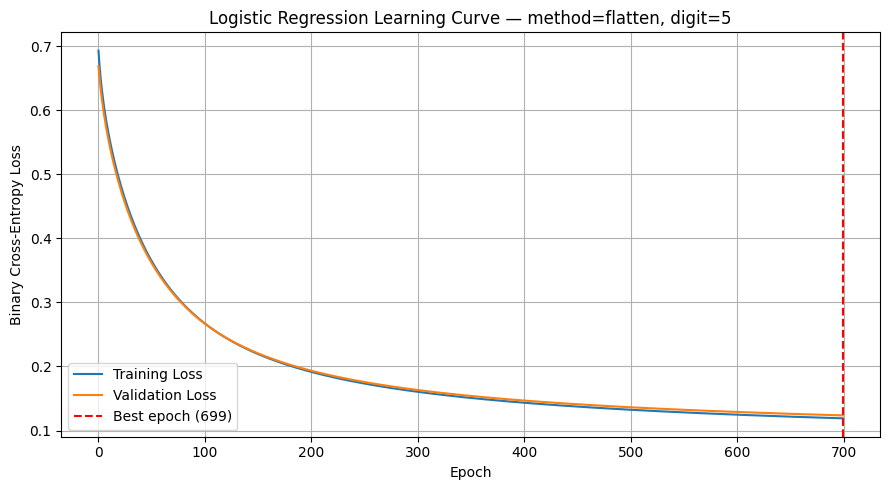

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses,   label="Validation Loss")
plt.axvline(best_epoch, color="red", linestyle="--", label=f"Best epoch ({best_epoch})")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title(f"Logistic Regression Learning Curve — method={method}, digit={target_digit}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. Evaluation metrics (manual)

All metrics computed from scratch — no sklearn.

| Metric | Formula |
|---|---|
| Accuracy  | $ (TP + TN) / (TP + TN + FP + FN) $ |
| Precision | $ TP / (TP + FP) $ |
| Recall    | $ TP / (TP + FN) $ |
| F1        | $ 2 \cdot P \cdot R / (P + R) $ |


In [15]:
def evaluate(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1_score  = 2 * precision * recall / (precision + recall + 1e-8)

    return accuracy, precision, recall, f1_score, int(TP), int(TN), int(FP), int(FN)


## 7. Final test evaluation

The test set is used **only once**, after training is fully complete.


In [16]:
y_test_pred       = predict_binary(X_test, W, b)
final_predictions = convert_to_class_1_class_2(y_test_pred)

accuracy, precision, recall, f1, TP, TN, FP, FN = evaluate(y_test, y_test_pred)

print("FINAL TEST RESULTS")
print("==================")
print(f"Target digit    : {target_digit}")
print(f"Class 1         : digit {target_digit}")
print(f"Class 2         : all other digits")
print(f"Feature method  : {method}")
print(f"Best val epoch  : {best_epoch}")

print(f"\nAccuracy  : {round(accuracy,  4)}")
print(f"Precision : {round(precision, 4)}")
print(f"Recall    : {round(recall,    4)}")
print(f"F1 Score  : {round(f1,        4)}")

print("\nConfusion Matrix")
print("  Rows = Actual | Columns = Predicted")
print("  [[TN, FP],")
print("   [FN, TP]]")
print(f"  [[{TN}, {FP}],")
print(f"   [{FN}, {TP}]]")

print("\nFirst 20 predictions (Class 1 / Class 2):")
print(final_predictions[:20])

# Note on low recall:
# One-vs-all binary classification on MNIST has strong class imbalance
# (~9% positive, ~91% negative). This suppresses recall.
# Oversampling (handle_imbalance=True in preprocess_mnist) can improve recall.


FINAL TEST RESULTS
Target digit    : 5
Class 1         : digit 5
Class 2         : all other digits
Feature method  : flatten
Best val epoch  : 699

Accuracy  : 0.9714
Precision : 0.904
Recall    : 0.7601
F1 Score  : 0.8258

Confusion Matrix
  Rows = Actual | Columns = Predicted
  [[TN, FP],
   [FN, TP]]
  [[9036, 72],
   [214, 678]]

First 20 predictions (Class 1 / Class 2):
[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2]


## 8. Visualise sample predictions

Shows test images with actual vs predicted class labels.
Undo standardisation using the saved `mean` and `std` from preprocessing.


NameError: name 'std' is not defined

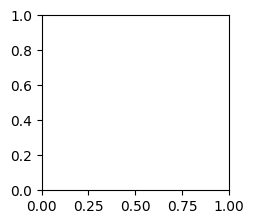

In [17]:
plt.figure(figsize=(14, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Undo standardisation to recover pixel values
    if method == "flatten":
        image = (X_test[i] * std + mean).reshape(28, 28)
    else:
        # For PCA / HOG we can't fully recover the image,
        # so we reconstruct an approximate version from the raw data.
        # A placeholder grey image is shown instead.
        image = np.full((28, 28), 0.5)

    predicted_class = int(final_predictions[i])
    actual_class    = 1 if y_test[i] == 1 else 2
    correct         = predicted_class == actual_class

    plt.imshow(image, cmap="gray", vmin=0, vmax=1)
    color = "green" if correct else "red"
    plt.title(
        f"Act: C{actual_class}\nPred: C{predicted_class}",
        color=color, fontsize=9
    )
    plt.axis("off")

plt.suptitle(
    f"Sample Predictions — digit={target_digit}, method={method}  |  green=correct, red=wrong",
    fontsize=10
)
plt.tight_layout()
plt.show()


## 9. Result row for report table

Run the notebook **three times** (method = `flatten`, `pca`, `hog`), copy each `results_row` into your comparison table.


In [ ]:
results_row = {
    "model"        : "Logistic Regression",
    "target_digit" : target_digit,
    "method"       : method,
    "best_epoch"   : best_epoch,
    "accuracy"     : round(float(accuracy),  4),
    "precision"    : round(float(precision), 4),
    "recall"       : round(float(recall),    4),
    "f1"           : round(float(f1),        4),
}

results_row
